<a href="https://colab.research.google.com/github/stephinsebastian444-SS/ICT_repository1/blob/main/AI%26ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train Test Split
from sklearn.model_selection import train_test_split

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [3]:
df = pd.read_csv("/content/diabetes_prediction_dataset.csv")
print(df.head())

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


In [4]:
print("Dataset Shape:", df.shape)
print(df.info())
print(df.isnull().sum())

Dataset Shape: (100000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
None
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int6

In [5]:
print("Duplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)
print("New Shape:", df.shape)

Duplicate Rows: 3854
New Shape: (96146, 9)


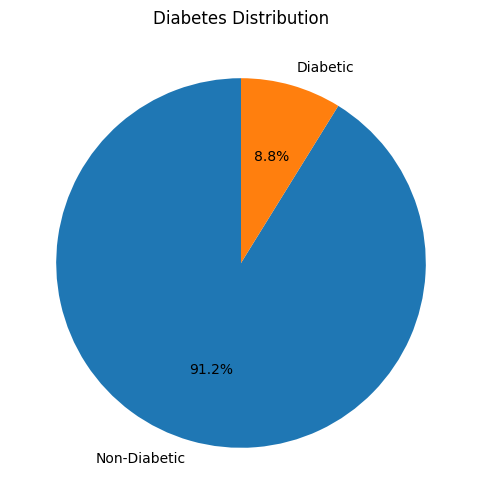

In [6]:
plt.figure(figsize=(6,6))
diabetes_counts = df['diabetes'].value_counts()
plt.pie(diabetes_counts,labels=['Non-Diabetic', 'Diabetic'],autopct='%1.1f%%',startangle=90)
plt.title('Diabetes Distribution')
plt.show()

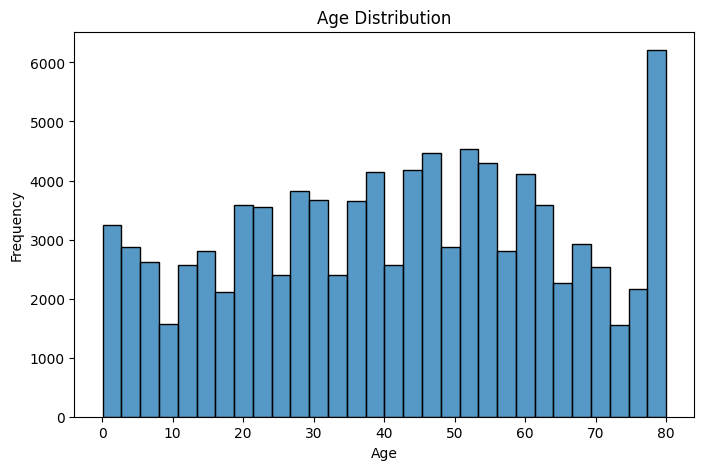

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

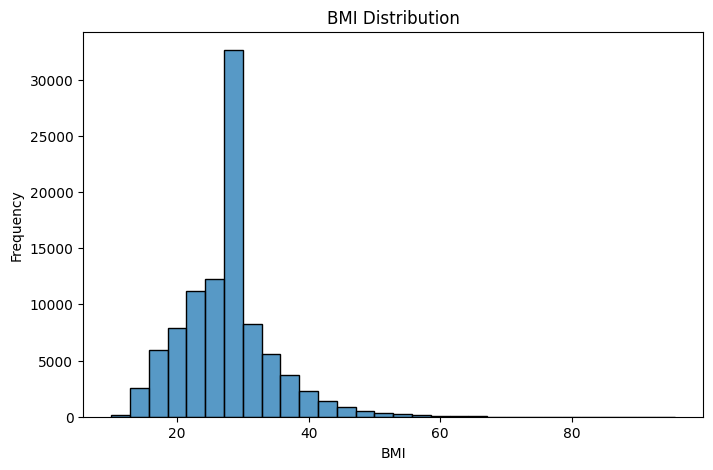

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['bmi'], bins=30)
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

In [9]:
df = pd.get_dummies(df, columns=['gender'], drop_first=True)
df = pd.get_dummies(df, columns=['smoking_history'], drop_first=True)
print(df.head())

    age  hypertension  heart_disease    bmi  HbA1c_level  blood_glucose_level  \
0  80.0             0              1  25.19          6.6                  140   
1  54.0             0              0  27.32          6.6                   80   
2  28.0             0              0  27.32          5.7                  158   
3  36.0             0              0  23.45          5.0                  155   
4  76.0             1              1  20.14          4.8                  155   

   diabetes  gender_Male  gender_Other  smoking_history_current  \
0         0        False         False                    False   
1         0        False         False                    False   
2         0         True         False                    False   
3         0        False         False                     True   
4         0         True         False                     True   

   smoking_history_ever  smoking_history_former  smoking_history_never  \
0                 False             

In [10]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']
print(X.head())
print(y.head())

    age  hypertension  heart_disease    bmi  HbA1c_level  blood_glucose_level  \
0  80.0             0              1  25.19          6.6                  140   
1  54.0             0              0  27.32          6.6                   80   
2  28.0             0              0  27.32          5.7                  158   
3  36.0             0              0  23.45          5.0                  155   
4  76.0             1              1  20.14          4.8                  155   

   gender_Male  gender_Other  smoking_history_current  smoking_history_ever  \
0        False         False                    False                 False   
1        False         False                    False                 False   
2         True         False                    False                 False   
3        False         False                     True                 False   
4         True         False                     True                 False   

   smoking_history_former  smoking_his

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

X_train Shape: (76916, 13)
X_test Shape: (19230, 13)


In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)
print("Logistic Regression Accuracy:", lr_accuracy)
print(confusion_matrix(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.9570982839313572
[[17325   184]
 [  641  1080]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     17509
           1       0.85      0.63      0.72      1721

    accuracy                           0.96     19230
   macro avg       0.91      0.81      0.85     19230
weighted avg       0.95      0.96      0.95     19230



In [14]:
svm_model = SVC()
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_pred)
print("SVM Accuracy:", svm_accuracy)
print(confusion_matrix(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.960374414976599
[[17477    32]
 [  730   991]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     17509
           1       0.97      0.58      0.72      1721

    accuracy                           0.96     19230
   macro avg       0.96      0.79      0.85     19230
weighted avg       0.96      0.96      0.96     19230



In [15]:
DT_model = DecisionTreeClassifier(random_state=42)
DT_model.fit(X_train, y_train)
DT_pred = DT_model.predict(X_test)
DT_accuracy = accuracy_score(y_test, DT_pred)
print("Decision Tree Accuracy:", DT_accuracy)
print(confusion_matrix(y_test, DT_pred))
print(classification_report(y_test, DT_pred))

Decision Tree Accuracy: 0.948361934477379
[[16970   539]
 [  454  1267]]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     17509
           1       0.70      0.74      0.72      1721

    accuracy                           0.95     19230
   macro avg       0.84      0.85      0.85     19230
weighted avg       0.95      0.95      0.95     19230



In [16]:
RF_model = RandomForestClassifier(n_estimators=100,random_state=42)
RF_model.fit(X_train, y_train)
RF_pred = RF_model.predict(X_test)
RF_accuracy = accuracy_score(y_test, RF_pred)
print("Random Forest Accuracy:", RF_accuracy)
print(confusion_matrix(y_test, RF_pred))
print(classification_report(y_test, RF_pred))

Random Forest Accuracy: 0.96801872074883
[[17434    75]
 [  540  1181]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17509
           1       0.94      0.69      0.79      1721

    accuracy                           0.97     19230
   macro avg       0.96      0.84      0.89     19230
weighted avg       0.97      0.97      0.97     19230



In [17]:
models = ['Logistic Regression','SVM','Decision Tree','Random Forest']
accuracies = [lr_accuracy,svm_accuracy,DT_accuracy,RF_accuracy]
comparison = pd.DataFrame({'Model': models,'Accuracy': accuracies})
print(comparison)

                 Model  Accuracy
0  Logistic Regression  0.957098
1                  SVM  0.960374
2        Decision Tree  0.948362
3        Random Forest  0.968019


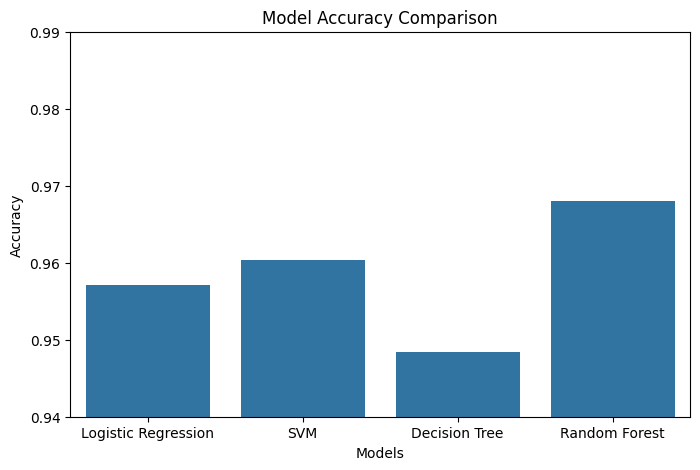

In [18]:
plt.figure(figsize=(8,5))
sns.barplot(x=models, y=accuracies)
plt.ylim(0.94, 0.99)
plt.title('Model Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.show()

In [19]:
sample_data = [[
    45,     # age
    0,      # hypertension
    0,      # heart_disease
    27.5,   # bmi
    6.5,    # HbA1c_level
    140,    # blood_glucose_level
    1,      # gender_Male
    0,      # smoking_history_current
    0,      # smoking_history_ever
    0,      # smoking_history_former
    1,      # smoking_history_never
    0,      # smoking_history_not current
    0       # smoking_history_No Info
]]
sample_data = scaler.transform(sample_data)
prediction = RF_model.predict(sample_data)
if prediction[0] == 1:
    print("Person is Diabetic")
    print()
    print("Diet Recommendation:")
    print("- Avoid sugary foods")
    print("- Eat more vegetables")
    print("- Drink plenty of water")
    print("- Exercise regularly")
    print("- Reduce carbohydrate intake")

else:
    print("Person is Non-Diabetic")
    print()
    print("Diet Recommendation:")
    print("- Maintain balanced diet")
    print("- Continue regular exercise")
    print("- Avoid excessive sugar intake")

Person is Non-Diabetic

Diet Recommendation:
- Maintain balanced diet
- Continue regular exercise
- Avoid excessive sugar intake


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [20]:
!pip install streamlit

!pip install pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 88.3 MB/s eta 0:00:00


In [21]:
import pickle

pickle.dump(RF_model, open("diabetes_model.pkl", "wb"))

pickle.dump(scaler, open("scaler.pkl", "wb"))

In [22]:
!streamlit run app.py &>/dev/null&

In [23]:
%%writefile app.py
import streamlit as st
import numpy as np
import pandas as pd
import pickle
st.set_page_config(
    page_title="Diabetes Prediction System",
    page_icon="🩺",
    layout="centered"
)

model = pickle.load(open("diabetes_model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))

st.title("🩺 Diabetes Prediction System")
st.markdown(
    "Enter the patient details below to predict the likelihood of diabetes."
)

st.divider()
def yes_no_to_binary(value):
    return 1 if value == "Yes" else 0

age = st.number_input(
    "Age",
    min_value=1,
    max_value=100,
    value=25
)

hypertension = yes_no_to_binary(
    st.selectbox(
        "Hypertension",
        ["No", "Yes"]
    )
)

heart_disease = yes_no_to_binary(
    st.selectbox(
        "Heart Disease",
        ["No", "Yes"]
    )
)

bmi = st.number_input(
    "BMI",
    min_value=10.0,
    max_value=60.0,
    value=24.0,
    step=0.1
)

HbA1c_level = st.number_input(
    "HbA1c Level",
    min_value=3.0,
    max_value=15.0,
    value=5.5,
    step=0.1
)

blood_glucose_level = st.number_input(
    "Blood Glucose Level",
    min_value=50,
    max_value=300,
    value=100
)


gender_male = yes_no_to_binary(
    st.selectbox(
        "Gender Male",
        ["No", "Yes"]
    )
)
st.subheader("Smoking History")

smoking_current = yes_no_to_binary(
    st.selectbox(
        "Current Smoker",
        ["No", "Yes"]
    )
)

smoking_ever = yes_no_to_binary(
    st.selectbox(
        "Ever Smoked",
        ["No", "Yes"]
    )
)

smoking_former = yes_no_to_binary(
    st.selectbox(
        "Former Smoker",
        ["No", "Yes"]
    )
)

smoking_never = yes_no_to_binary(
    st.selectbox(
        "Never Smoked",
        ["No", "Yes"]
    )
)

smoking_not_current = yes_no_to_binary(
    st.selectbox(
        "Not Currently Smoking",
        ["No", "Yes"]
    )
)

smoking_no_info = yes_no_to_binary(
    st.selectbox(
        "Smoking Info Not Available",
        ["No", "Yes"]
    )
)

st.divider()
if st.button("Predict Diabetes"):

    sample_data = [[
        age,
        hypertension,
        heart_disease,
        bmi,
        HbA1c_level,
        blood_glucose_level,
        gender_male,
        smoking_current,
        smoking_ever,
        smoking_former,
        smoking_never,
        smoking_not_current,
        smoking_no_info
    ]]
    sample_df = pd.DataFrame(sample_data)
    scaled_data = scaler.transform(sample_df)
    prediction = model.predict(scaled_data)
    probability = model.predict_proba(scaled_data)[0][1]

    st.subheader("Prediction Result")

    if prediction[0] == 1:
        st.error("⚠️ Person is Likely Diabetic")
        st.write(f"Prediction Confidence: {probability * 100:.2f}%")

        st.markdown("### Recommendations")
        st.write("- Reduce sugary foods")
        st.write("- Exercise regularly")
        st.write("- Monitor blood sugar levels")
        st.write("- Increase vegetable intake")

    else:
        st.success("✅ Person is Likely Non-Diabetic")
        st.write(f"Prediction Confidence: {(1 - probability) * 100:.2f}%")

        st.markdown("### Health Tips")
        st.write("- Maintain a balanced diet")
        st.write("- Continue regular exercise")
        st.write("- Get periodic health checkups")


Writing app.py


In [24]:
from pyngrok import ngrok
ngrok.set_auth_token("3DevG5E9LN3nEWlvWww7PgIG77Z_7CDjJopu86dfJprWAKKp7")


In [25]:
public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://down-reviver-headrest.ngrok-free.dev" -> "http://localhost:8501"


In [29]:
from google.colab import files

files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
import os

print(os.listdir())


['.config', 'diabetes_model.pkl', 'diabetes_prediction_dataset.csv.zip', 'diabetes_prediction_dataset.csv', 'scaler.pkl', 'app.py', 'sample_data']
